<a href="https://colab.research.google.com/github/sk-shahsi/ML_Model/blob/master/covid_19_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [52]:
df = pd.read_csv("/content/Covid_19_Clean_Complete (2).csv")

In [53]:
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [54]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df.shape

(49068, 10)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [58]:
df.rename(columns={"Province/State":"State","Country/Region":"Country"},inplace=True)

In [59]:
df

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [60]:
df['Date'].value_counts()

,count
Date,
2020-01-22,261
2020-01-23,261
2020-01-24,261
2020-01-25,261
2020-01-26,261
...,...
2020-07-23,261
2020-07-24,261
2020-07-25,261


In [62]:
confiremed_cases = df.groupby(["Date"])["Confirmed"].sum().reset_index()
confiremed_cases



,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


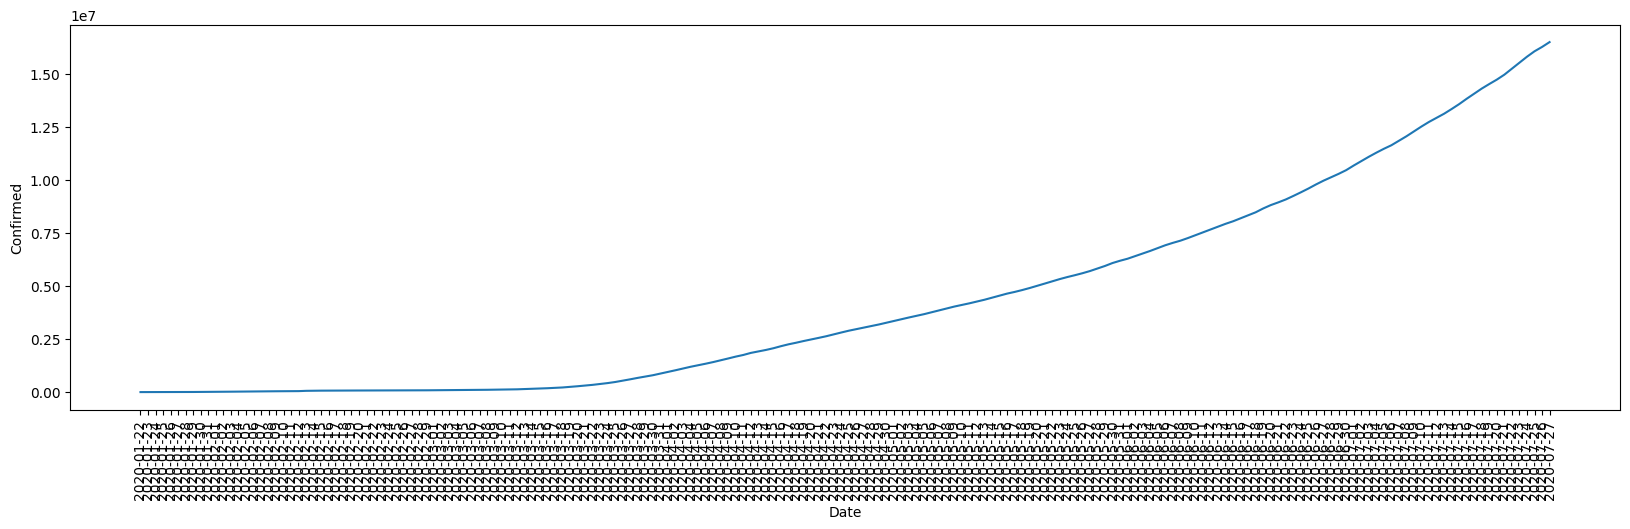

In [63]:
plt.figure(figsize=(20,5))
sns.lineplot(data=confiremed_cases, x="Date", y="Confirmed")
plt.xticks(rotation=90)
plt.show()

In [68]:
df.columns

Index(['State', 'Country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [69]:
date_case = df.groupby(["Date"])["Deaths"].sum().reset_index

In [72]:
plt.figure(figsize=(20,5))
sns.lineplot(data=date_case, x="Date", y="Deaths")
plt.xticks(rotation=90)
plt.show()

TypeError: Data source must be a DataFrame or Mapping, not <class 'method'>.

<Figure size 2000x500 with 0 Axes>

In [73]:
most_affected = df.groupby("Country")["Deaths"].sum().sort_values(ascending=False)

In [74]:
print(most_affected.head(3))

Country
US                11011411
United Kingdom     3997775
Brazil             3938034
Name: Deaths, dtype: int64


In [75]:
most_affected = df.groupby("Country")["Confirmed", "Active", "Recovered", "Deaths"].sum().sort_values(ascending=False).head(3)

ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

In [78]:
top_3 = df.groupby("Country")[
    ["Confirmed", "Active", "Recovered", "Deaths"]
].sum().sort_values(
    by="Confirmed",
    ascending=False
).head(3)

print(top_3)

         Confirmed     Active  Recovered    Deaths
Country                                           
US       224345948  156981121   56353416  11011411
Brazil    89524967   31094060   54492873   3938034
Russia    45408411   19668578   25120448    619385
